## Capstone 1
## Forest Cover Type Project
## **Reserach Question:** What would be the type tree that grow best according to the surrounding charateristic of a certain area?

## 1. Load the dataset



In [ ]:
# import neccessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# load the dataset using pandas
fct = pd.read_csv('Forest Cover Type Dataset.csv')
fct.head(10) # load the first 10 rows

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type
0,2596,51,3,258,0,510,221,232,148,6279,...,0,0,0,0,0,0,0,0,0,5
1,2590,56,2,212,-6,390,220,235,151,6225,...,0,0,0,0,0,0,0,0,0,5
2,2804,139,9,268,65,3180,234,238,135,6121,...,0,0,0,0,0,0,0,0,0,2
3,2785,155,18,242,118,3090,238,238,122,6211,...,0,0,0,0,0,0,0,0,0,2
4,2595,45,2,153,-1,391,220,234,150,6172,...,0,0,0,0,0,0,0,0,0,5
5,2579,132,6,300,-15,67,230,237,140,6031,...,0,0,0,0,0,0,0,0,0,2
6,2606,45,7,270,5,633,222,225,138,6256,...,0,0,0,0,0,0,0,0,0,5
7,2605,49,4,234,7,573,222,230,144,6228,...,0,0,0,0,0,0,0,0,0,5
8,2617,45,9,240,56,666,223,221,133,6244,...,0,0,0,0,0,0,0,0,0,5
9,2612,59,10,247,11,636,228,219,124,6230,...,0,0,0,0,0,0,0,0,0,5


## 2. Explore Data Analysis (EDA)

In [ ]:
# Chack for rows and columns count
fct.shape

(581012, 55)

In [ ]:
# check on all data types
fct.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 581012 entries, 0 to 581011
Data columns (total 55 columns):
 #   Column                              Non-Null Count   Dtype
---  ------                              --------------   -----
 0   Elevation                           581012 non-null  int64
 1   Aspect                              581012 non-null  int64
 2   Slope                               581012 non-null  int64
 3   Horizontal_Distance_To_Hydrology    581012 non-null  int64
 4   Vertical_Distance_To_Hydrology      581012 non-null  int64
 5   Horizontal_Distance_To_Roadways     581012 non-null  int64
 6   Hillshade_9am                       581012 non-null  int64
 7   Hillshade_Noon                      581012 non-null  int64
 8   Hillshade_3pm                       581012 non-null  int64
 9   Horizontal_Distance_To_Fire_Points  581012 non-null  int64
 10  Wilderness_Area1                    581012 non-null  int64
 11  Wilderness_Area2                    581012 non-null 

* All columns are interger values!
* No need to change dtype before EDA visualize distribution!

In [ ]:
# check on all missing values in dataset
print('All Missing Values per Column:')
print(fct.isnull().sum())

All Missing Values per Column:
Elevation                             0
Aspect                                0
Slope                                 0
Horizontal_Distance_To_Hydrology      0
Vertical_Distance_To_Hydrology        0
Horizontal_Distance_To_Roadways       0
Hillshade_9am                         0
Hillshade_Noon                        0
Hillshade_3pm                         0
Horizontal_Distance_To_Fire_Points    0
Wilderness_Area1                      0
Wilderness_Area2                      0
Wilderness_Area3                      0
Wilderness_Area4                      0
Soil_Type1                            0
Soil_Type2                            0
Soil_Type3                            0
Soil_Type4                            0
Soil_Type5                            0
Soil_Type6                            0
Soil_Type7                            0
Soil_Type8                            0
Soil_Type9                            0
Soil_Type10                           0
Soil_Type

There are no missing values appear in the dataset!

<Axes: >

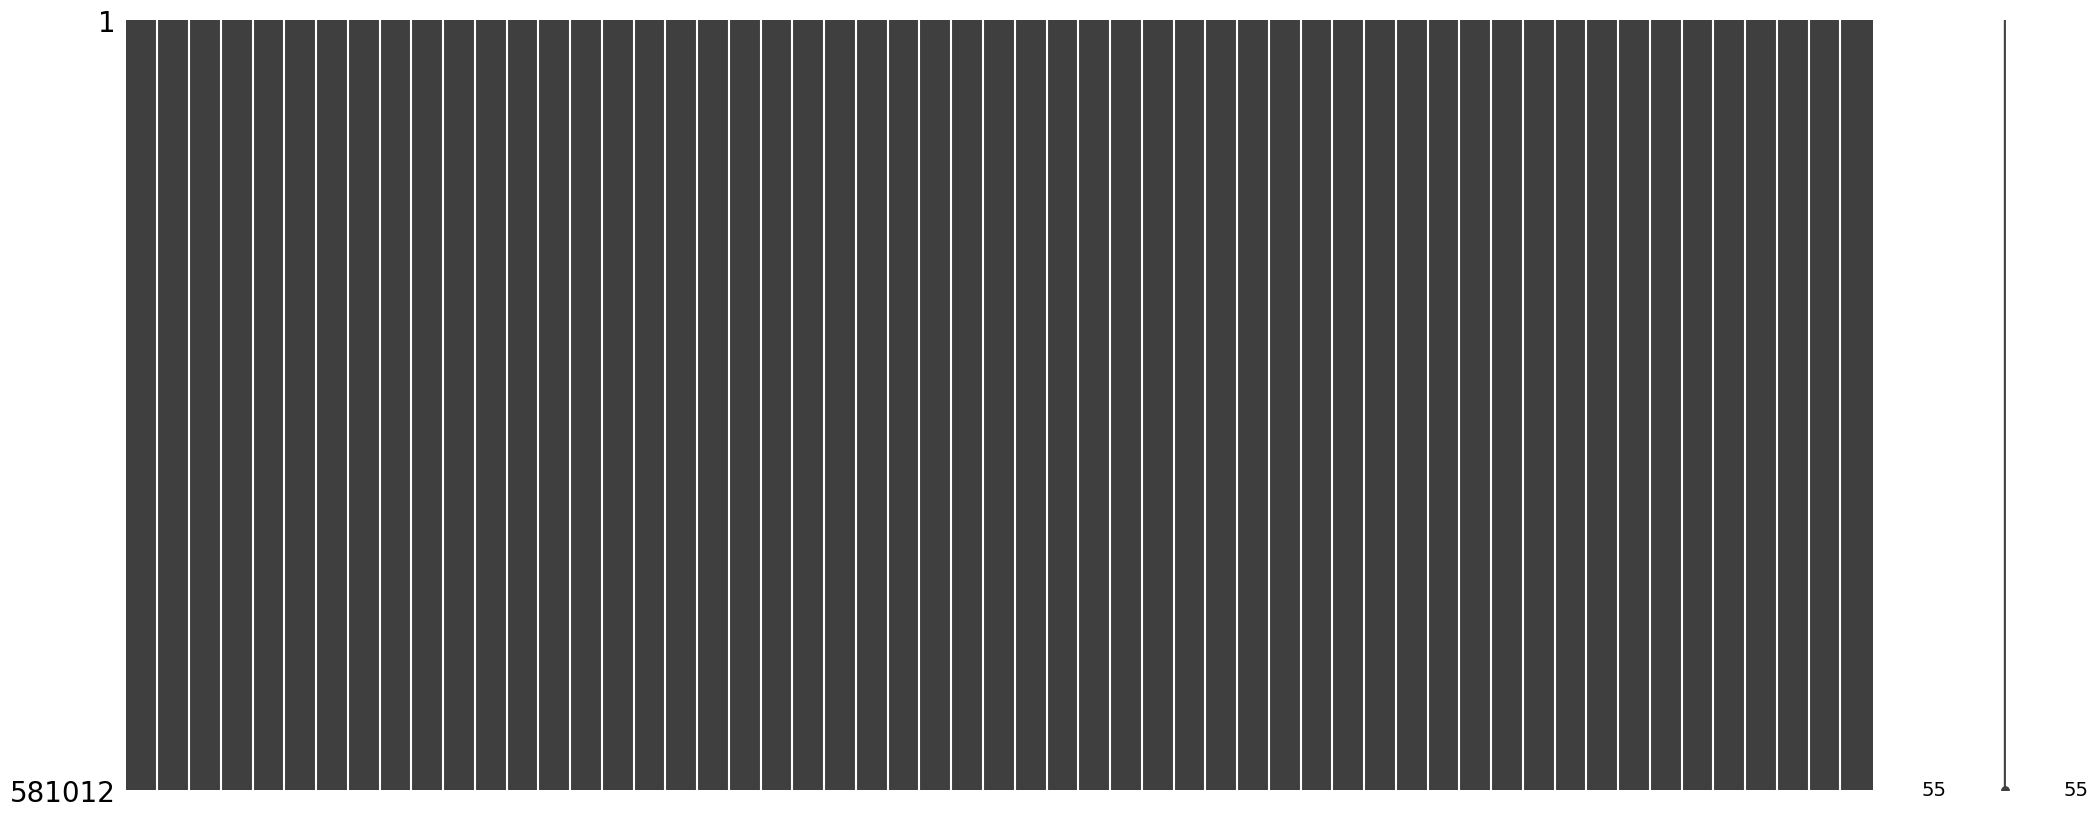

In [ ]:
# visualize missingness using msno
# --optional since there are no missingness show above--
import missingno as msno
msno.matrix(fct)

* dark: values present
* white space: missingness
* Conclusion: no missingness appear!

In [ ]:
# check for duplicates
print('Duplicate:', fct.duplicated().sum())

Duplicate: 0


In [ ]:
# check for all statistical informations:
fct.describe()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type
count,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,...,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000
mean,2959.365301,155.656807,14.103704,269.428217,46.418855,2350.146611,212.146049,223.318716,142.528263,1980.291226,...,0.090392,0.077716,0.002773,0.003255,0.000205,0.000513,0.026803,0.023762,0.015060,2.051471
std,279.984734,111.913721,7.488242,212.549356,58.295232,1559.254870,26.769889,19.768697,38.274529,1324.195210,...,0.286743,0.267725,0.052584,0.056957,0.014310,0.022641,0.161508,0.152307,0.121791,1.396504
min,1859.000000,0.000000,0.000000,0.000000,-173.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2809.000000,58.000000,9.000000,108.000000,7.000000,1106.000000,198.000000,213.000000,119.000000,1024.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,2996.000000,127.000000,13.000000,218.000000,30.000000,1997.000000,218.000000,226.000000,143.000000,1710.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
75%,3163.000000,260.000000,18.000000,384.000000,69.000000,3328.000000,231.000000,237.000000,168.000000,2550.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
max,3858.000000,360.000000,66.000000,1397.000000,601.000000,7117.000000,254.000000,254.000000,254.000000,7173.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,7.000000


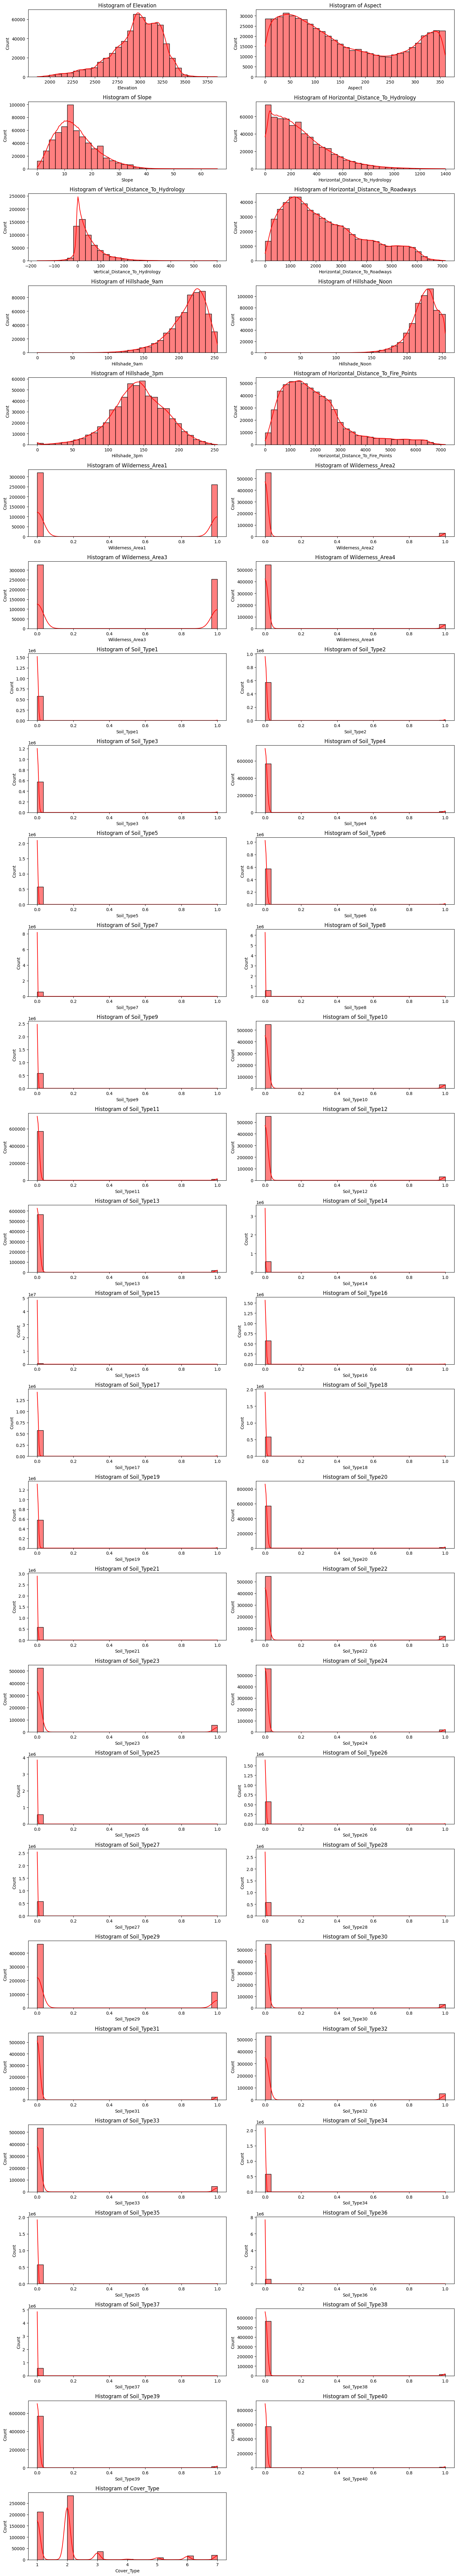

In [ ]:
# Using histogram/bar graph visualization
cols = fct.columns
n_features = len(cols)

# Calculate the number of rows needed based on the number of features and columns per row
n_cols_per_row = 2
n_rows = (n_features + n_cols_per_row - 1) // n_cols_per_row # Use integer division and ceiling

fig, axes = plt.subplots(n_rows, n_cols_per_row, figsize=(15, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.histplot(fct[col], bins=30, kde=True, ax=axes[i], color="red")
    axes[i].set_title(f"Histogram of {col}")

# Hide any unused subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

* Personally I think histogram would be the best choice to visualize the distribution in each column! It helps define the best characteristic of each catergory such as skewnes, outliers, etc.
* Cover_Type is the Target Variable!!
* Challenge: Since this is a large dataset, it took a long time to visualize all of the histogram distributions.

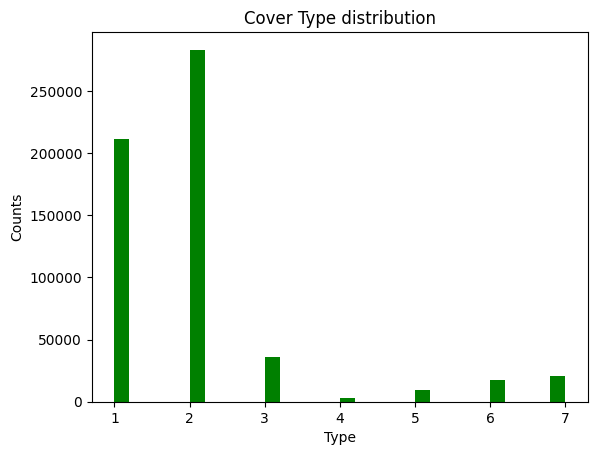

In [ ]:
# Target variable using Histogram plot
target_var = fct['Cover_Type'].dropna()

plt.figure()
plt.hist(target_var, bins=30, color='green')
plt.title('Cover Type distribution')
plt.xlabel('Type')
plt.ylabel('Counts')
plt.show()

In [ ]:
# check on value count of each target 'Cover Type' value
fct['Cover_Type'].value_counts()

,count
Cover_Type,
2,283301
1,211840
3,35754
7,20510
6,17367
5,9493
4,2747


## 3. Train-Test-Split

In [ ]:
# import the libraries
from sklearn.model_selection import train_test_split

In [ ]:
# splitting data target and feature variables
fct_cleaned = fct.dropna(subset=['Cover_Type'])
X = fct_cleaned.drop('Cover_Type', axis=1)
y = fct_cleaned['Cover_Type']

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

print('\nTrain class distribution:')
print(y_train.value_counts(normalize=True))
print('\nTest class distribution:')
print(y_test.value_counts(normalize=True))

(464809, 54)
(116203, 54)
(464809,)
(116203,)

Train class distribution:
Cover_Type
2    0.487945
1    0.364199
3    0.061602
7    0.035488
6    0.029857
5    0.016131
4    0.004778
Name: proportion, dtype: float64

Test class distribution:
Cover_Type
2    0.486218
1    0.366230
3    0.061281
7    0.034552
6    0.030025
5    0.017168
4    0.004527
Name: proportion, dtype: float64


## 4. Baseline Models (before tuning)

In [ ]:
# Import neccessary libraries
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

DECISION TREE MODEL

In [ ]:
# DECISION TREE MODEL
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(x_train, y_train)
dt_y_pred = dt_model.predict(x_test)

# classification
print('Decision Tree Accuracy:', accuracy_score(y_test, dt_y_pred))
print('Classification Report:')
print(classification_report(y_test, dt_y_pred))

# confusion matrix
print('\nConfusion Matrix:')
print(confusion_matrix(y_test, dt_y_pred))

Decision Tree Accuracy: 0.9389516621773965
Classification Report:
              precision    recall  f1-score   support

           1       0.94      0.94      0.94     42557
           2       0.95      0.95      0.95     56500
           3       0.93      0.93      0.93      7121
           4       0.85      0.81      0.83       526
           5       0.84      0.83      0.83      1995
           6       0.88      0.89      0.88      3489
           7       0.94      0.95      0.95      4015

    accuracy                           0.94    116203
   macro avg       0.90      0.90      0.90    116203
weighted avg       0.94      0.94      0.94    116203


Confusion Matrix:
[[39910  2414     1     0    36     4   192]
 [ 2386 53551   165     1   259    99    39]
 [    4   122  6650    51    16   276     2]
 [    0     2    72   427     0    25     0]
 [   49   251    28     0  1656    10     1]
 [    8   100   257    25     7  3092     0]
 [  165    26     0     0     1     0  3823]]


* Overall it performs very well: ~93.9% accuracy and weighted F1 ≈ 0.94. That means the features in this dataset separate the cover types strongly, and a single tree already captures most of the signal.
* Performance by class is solid for the big groups—Types 1 and 2 have F1 ≈ 0.92 and 0.96 with large support—so the model is especially reliable on the majority classes.
* The smaller classes (5, 6, 7) are a bit harder: F1s around 0.85–0.91 with recalls 0.84–0.92. The confusion matrix shows the main mix-ups are 1 ↔ 2, 3 ↔ 6, and some drift of Type 5 into 2/3/4. Those are likely ecologically similar in the feature space (slope/soil/elevation combinations), so the tree splits can blur those boundaries.
* **Conclusion:** The dataset is highly predictable with a simple model, but there’s mild class-imbalance/overlap affecting minority types. If you want to push recall/F1 for Types 5–6–7, try (a) an ensemble (Random Forest/Gradient Boosting) to reduce variance, and/or (b) class weights or light resampling to give minority classes more influence. That should tighten the confusions (esp. 3 vs 6, 1 vs 2) without sacrificing overall accuracy.

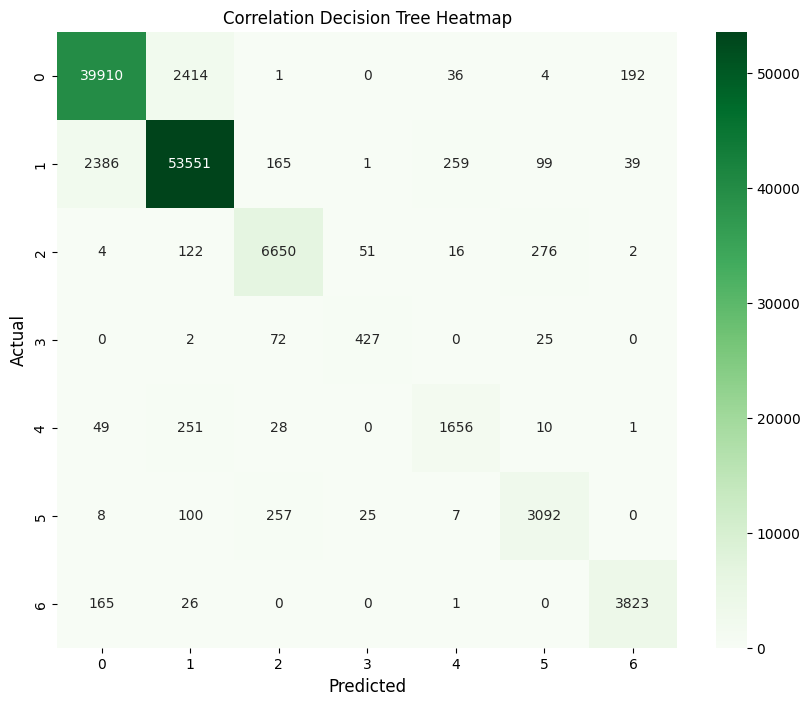

In [ ]:
# visualize decision tree model correlation using heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_test, dt_y_pred), annot=True, fmt='d', cmap='Greens')
plt.title('Correlation Decision Tree Heatmap', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.show()

* The decision tree does a solid job on Forest Cover Type, about 94% accuracy / weighted F1 ≈ 0.94—so the features clearly separate most classes. Most errors come from “look-alike” pairs, mainly Type 0 ↔ Type 1 and Type 2 ↔ Type 5 (plus a little 2 ↔ 3), and the smaller classes (5, 6, 7) have slightly lower recall. In short, the dataset is highly predictable with a single tree, but class overlap and minor imbalance cause those specific mix-ups. If I were improving this, I’d move to an ensemble (Random Forest or Gradient Boosting) and add class weights/oversampling for the small classes; that should clean up the confusion without hurting the strong overall score.

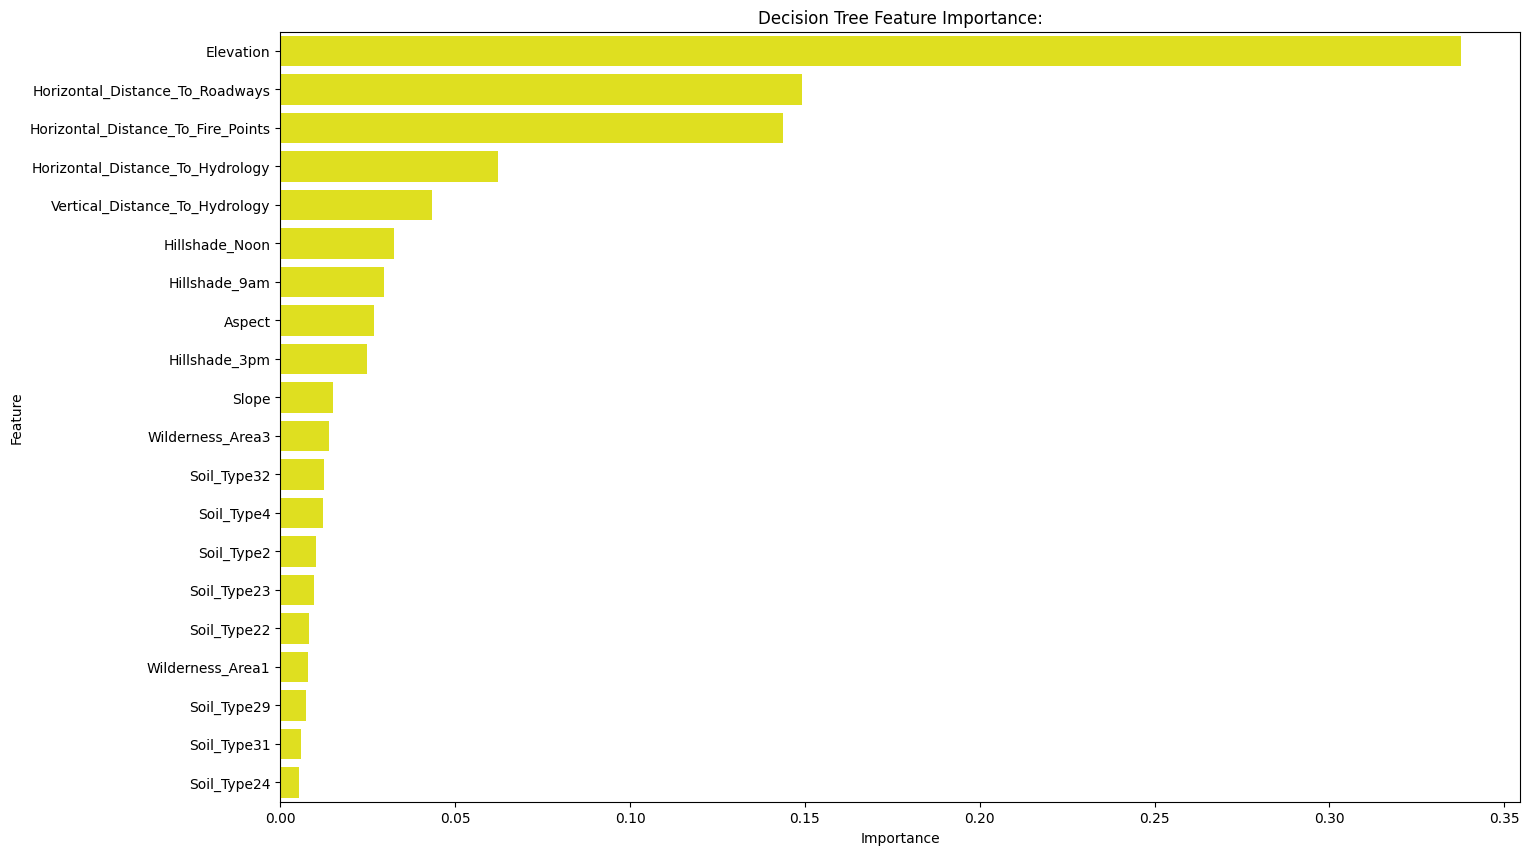

In [ ]:
# Feature Importance of Decision Tree Model
importance = dt_model.feature_importances_
indices = np.argsort(importance)[::-1][:20] # indicate top 20 features

plt.figure(figsize=(16, 10))
sns.barplot(x=importance[indices], y=x_train.columns[indices], color='yellow')
plt.title('Decision Tree Feature Importance:')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

* In conslusion to compare about the soil type only in this model, soil features barely matter. Elevation and distances do almost all the work, and only a few soils (e.g., Type32/Type4/Type2/Type23) get tiny importance. Conclusion: soils add little signal to this model; the tree doesn’t rely on them for splits.

RANDOM FOREST MODEL

In [ ]:
# RANDOM FOREST MODEL
rf = RandomForestClassifier(random_state=42)
rf.fit(x_train, y_train)
rf_y_pred = rf.predict(x_test)

# classification
print('Random Forest Accuracy:', accuracy_score(y_test, rf_y_pred))
print('Classification Report:')
print(classification_report(y_test, rf_y_pred))

# confusion matrix
print('\nConfusion Matrix:')
print(confusion_matrix(y_test, rf_y_pred))

Random Forest Accuracy: 0.9551646687262807
Classification Report:
              precision    recall  f1-score   support

           1       0.97      0.94      0.95     42557
           2       0.95      0.97      0.96     56500
           3       0.94      0.96      0.95      7121
           4       0.91      0.85      0.88       526
           5       0.94      0.77      0.85      1995
           6       0.93      0.90      0.92      3489
           7       0.97      0.96      0.97      4015

    accuracy                           0.96    116203
   macro avg       0.95      0.91      0.93    116203
weighted avg       0.96      0.96      0.95    116203


Confusion Matrix:
[[40166  2293     0     0     8     3    87]
 [ 1238 55013    97     0    75    63    14]
 [    2    97  6865    24     6   127     0]
 [    0     0    66   445     0    15     0]
 [   30   400    17     0  1536    12     0]
 [    1   107   227    19     5  3130     0]
 [  152    25     0     0     0     0  3838]]


* Overall it's better than the decision tree: about 95% accuracy and weighted F1 ≈ 0.95 but took a longer time to load
* Big classes (1 & 2) are very strong, especially Type 2 (recall ~0.98).
* Type 1: high precision, a little lower recall (it’s stricter about calling class 1).
* Smaller classes mostly improved (Types 6 & 7 look good).
* Type 5 is still hardest: great precision, but it misses more true Type-5 cases (lower recall).
* Main mix-ups are still 0 ↔ 1 and 2 ↔ 5, just less than before.
* **Conclusion:** Use Random Forest—it’s more accurate and stable.
If you need better catch rate for Type 5, try class weights = 'balanced' or light oversampling/SMOTE, and tune RF (n_estimators, max_depth).

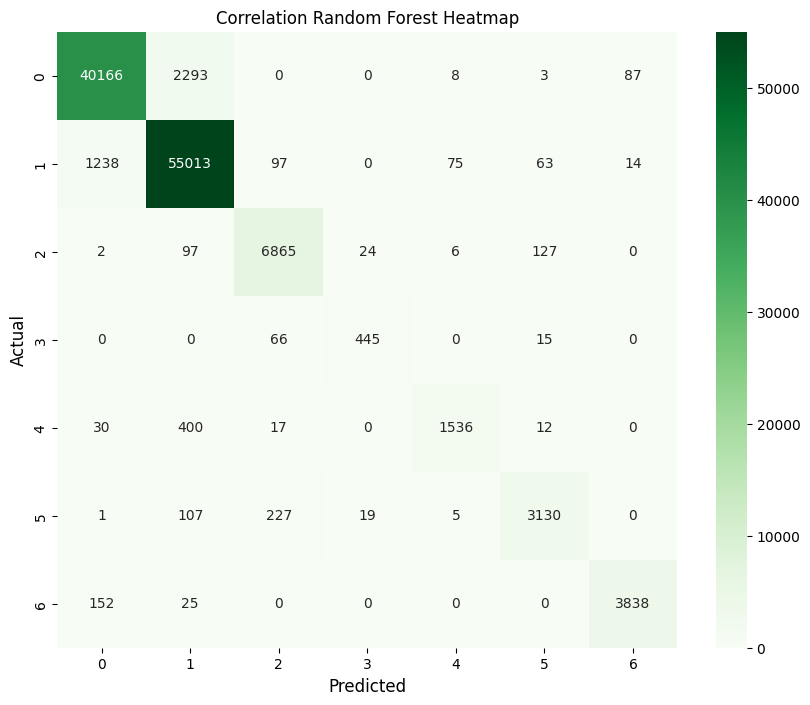

In [ ]:
# visualize random forest model correlation using heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_test, rf_y_pred), annot=True, fmt='d', cmap='Greens')
plt.title('Correlation Random Forest Heatmap', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.show()

* Diagonal is bright, most predictions correct.
* Biggest mistakes are still Type 0 - Type 1, especially 0 to 1 (1513) and some 1 to 0 (593).
* Type 5 to Type 2 (172) is the next notable mix up, smaller leaks: 2 to 5 (43) and 2 to 3 (18).
* Minor drifts: Type 4 to 1 (223) and Type 6 to 0 (60).
* **Conclusion:** The Random Forest tightened things up compared to the single tree, but look-alike pairs remain mainly (0,1) and (5,2). If the main purpose is to reduce those, add class weights/oversampling for Type 5, and tune RF (max_depth, max_features) or try GBM for finer boundaries.

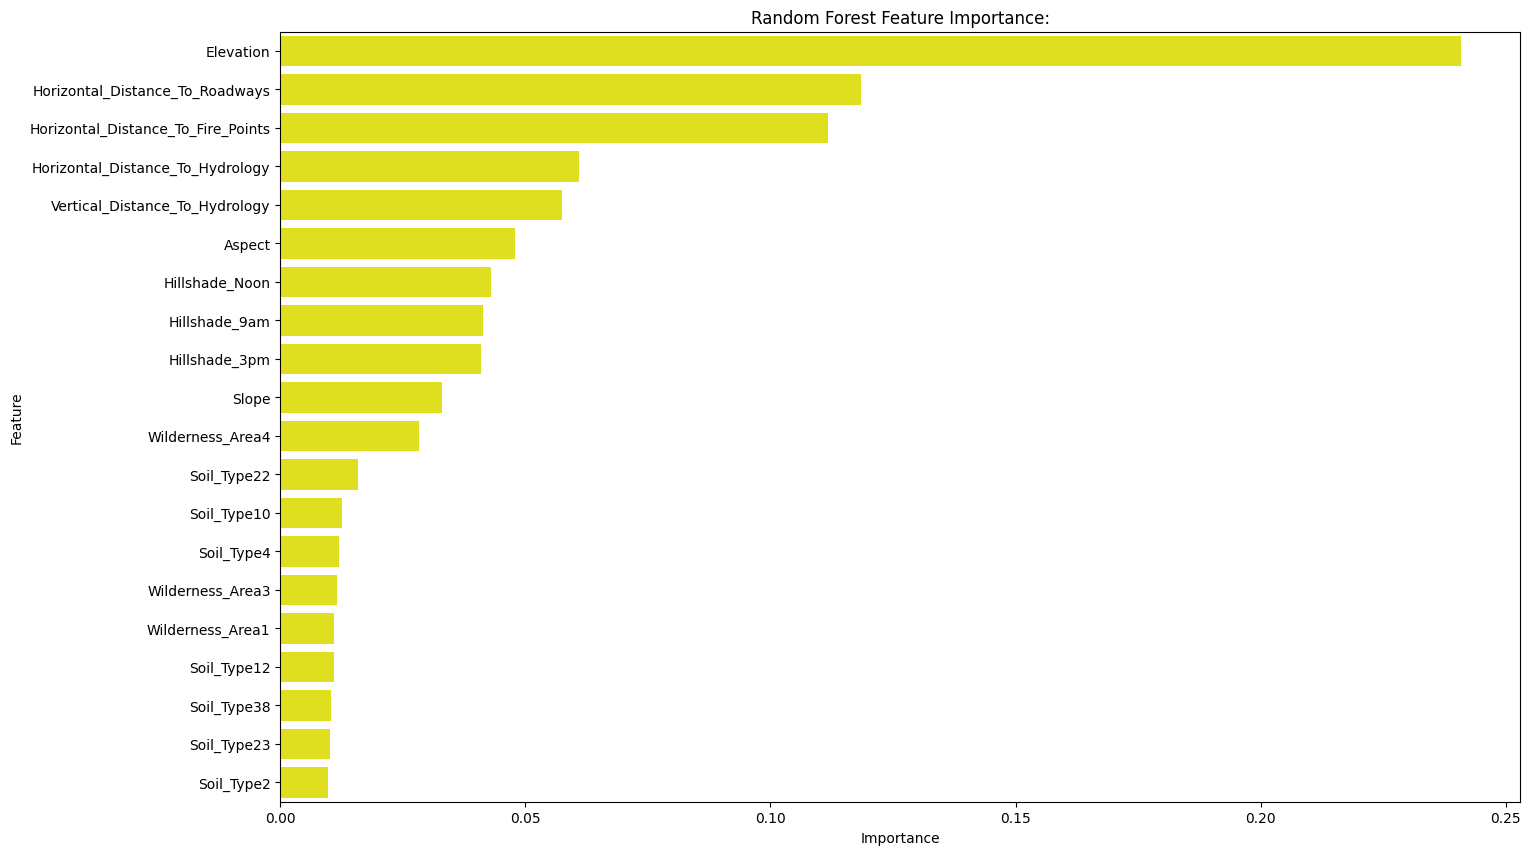

In [ ]:
# Feature Importance of Random Forest Model
importance = rf.feature_importances_
indices = np.argsort(importance)[::-1][:20] # indicate top 20 features

plt.figure(figsize=(16, 10))
sns.barplot(x=importance[indices], y=x_train.columns[indices], color='yellow')
plt.title('Random Forest Feature Importance:')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

* In conclusion for soil_type only, soils have small but consistent importance. A handful (Type22, Type12, Type38, Type23, Type2) show up, but they still trail terrain and distance features. Conclusion: soils help refine decisions in RF, but the model’s main power still comes from topography and proximity, not soil categories.

XGBOOST MODEL

In [ ]:
# XGBOOST MODEL
# y train for xgboost
xgb_y_train = y_train - 1
xgb_y_test = y_test - 1
print(np.unique(xgb_y_train))
print(np.unique(xgb_y_test))

# y predict for xgboost
xgb = XGBClassifier(random_state=42)
xgb.fit(x_train, xgb_y_train)
xgb_y_pred = xgb.predict(x_test)
xgb_y_pred = xgb_y_pred + 1
print(np.unique(xgb_y_pred))

# classification
print('\nXGBoost Accuracy:', accuracy_score(y_test, xgb_y_pred))
print('Classification Report:')
print(classification_report(y_test, xgb_y_pred))

# confusion matrix
print('\nConfusion Matrix:')
print(confusion_matrix(y_test, xgb_y_pred))

[0 1 2 3 4 5 6]
[0 1 2 3 4 5 6]
[1 2 3 4 5 6 7]

XGBoost Accuracy: 0.8711823274786366
Classification Report:
              precision    recall  f1-score   support

           1       0.86      0.84      0.85     42557
           2       0.87      0.90      0.88     56500
           3       0.90      0.91      0.91      7121
           4       0.91      0.86      0.89       526
           5       0.89      0.59      0.71      1995
           6       0.85      0.82      0.83      3489
           7       0.94      0.92      0.93      4015

    accuracy                           0.87    116203
   macro avg       0.89      0.83      0.86    116203
weighted avg       0.87      0.87      0.87    116203


Confusion Matrix:
[[35864  6450     1     0    22     3   217]
 [ 5303 50696   195     1   123   159    23]
 [    4   268  6500    29     1   319     0]
 [    0     0    57   452     0    17     0]
 [   29   744    30     0  1184     8     0]
 [    1   213   408    13     1  2853     0]
 [  3

* Overall, it shows 87% of accuracy and weighted F1= ~0.91 which is worse than Random Forest (~95%) and the single tree (~94%).
* Strong classes shows at Type 2 and 3 are good (F1 ~0.93–0.95).
* Weak spots:Type 1 recall drops to 0.82 (F1 0.86) → many 1’s get predicted as 0. Type 5 recall 0.77 (F1 0.82) → still the hardest; lots of 5 → 2 mistakes.
* Confusions: Mainly 0 ↔ 1 (bigger than RF) and 5 ↔ 2, some 4 to 1.
* **Conclusion:** With current settings, XGBoost underperforms RF on this dataset, especially on recall for Types 1 and 5. In my opinion, Random Forest model has performed better than XGBoost!

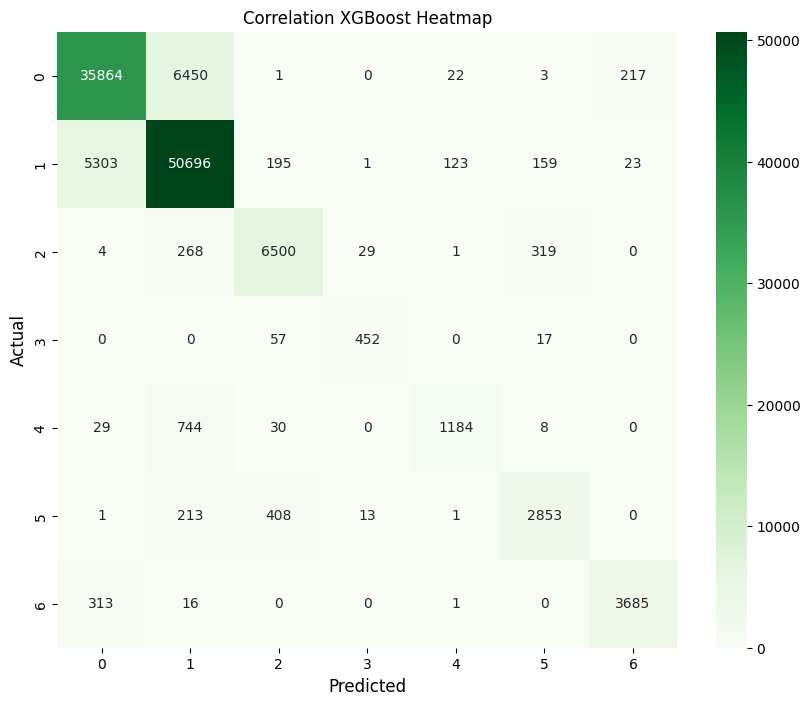

In [ ]:
# visualize xgboost model correlation using heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_test, xgb_y_pred), annot=True, fmt='d', cmap='Greens')
plt.title('Correlation XGBoost Heatmap', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.show()

* The diagonal’s still bright, but there’s more spill than Random Forest.
* Biggest confusion: Type 0 and Type 1 show lots of 0 to 1 (2,736) and 1 to 0 (1,380). That’s why Type-1 recall fell.
* Type 5 is still tough: many 5 to 2 (175) and some 2 to 5 (62).
* Smaller leaks: 4 to 1 (265), 2 to 3 (23), 3 to 2 (40), 6 to 0 (72).
* **Conclusion:** With current settings, XGBoost makes more 0/1 and 5/2 mix ups, so it underperforms than Random Forest.In my opinion, class weights/oversampling for Type 5 (and maybe 1) and tuning with early stopping and track macro F1/recall will be the next step!

### **Class Imbalance Conclusion:** It shows a severe imbalance!
* According to the classsification outcome of XGBoost, it says that:
  - 2 → 33,342 (≈59.2)
  - 1 → 15,825 (≈28.1%)
  - 3 → 3,177 (≈5.6%)
  - 4 → 520 (≈0.9%)
  - 5 → 1,254 (≈2.2%)
  - 6 → 1,392 (≈2.5%)
  - 7 → 853 (≈1.5%)
* Imbalance ratio (max/min) = 33,342 / 520 ≈ 64:1 (majority vs. rarest class).
* Head classes (1 & 2) make up ~87% of all samples; the four smallest (4–7) together are only ~7%.
* Metric symptoms match: macro recall 0.88 < weighted recall/F1 0.91, and minority classes (esp. type 5, recall 0.77) underperform with spillovers (e.g., 5 ↔ 2, 0 ↔ 1 in the confusion matrix).

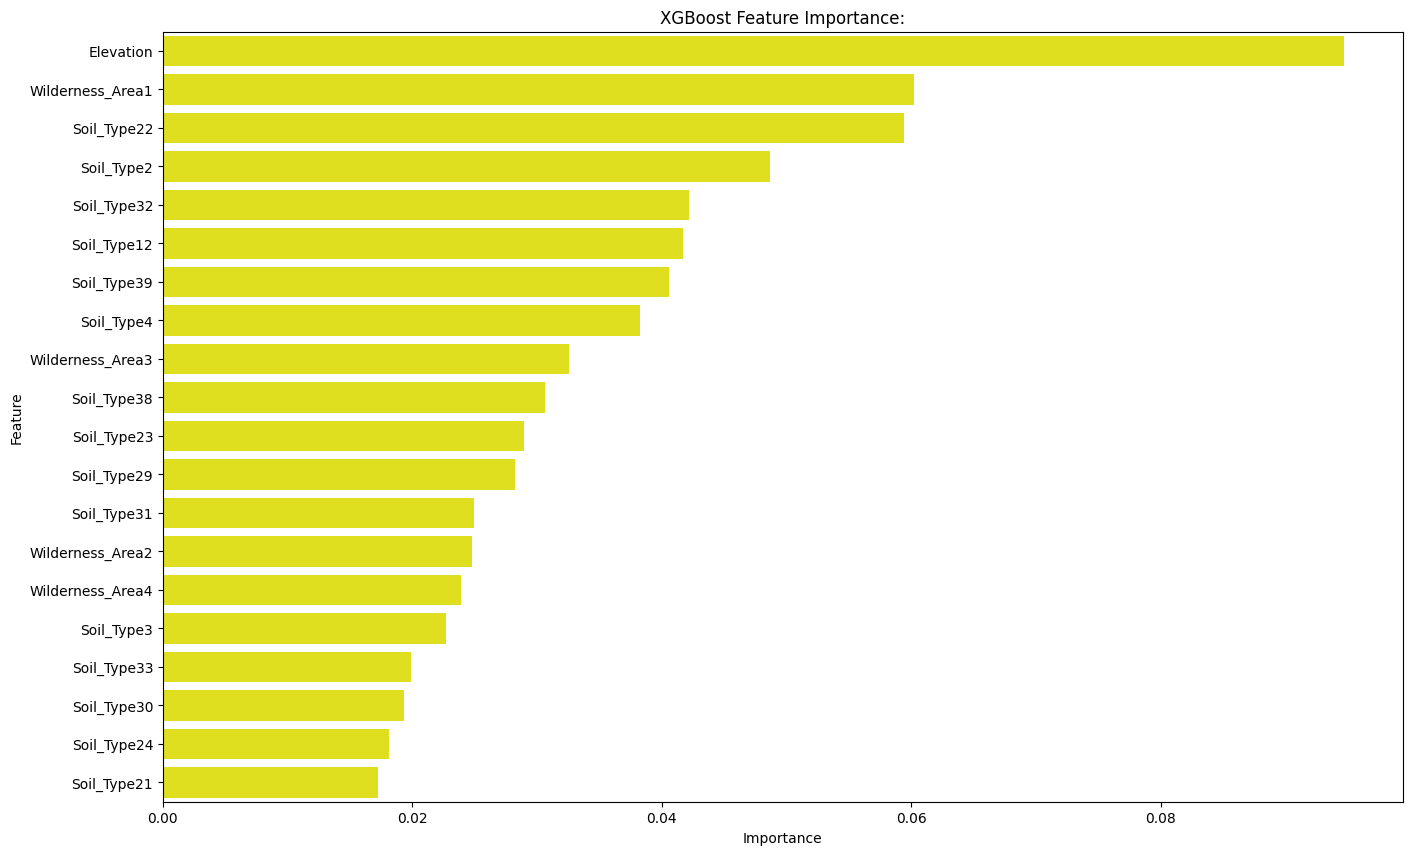

In [ ]:
# Feature Importance of XGBoost
importance = xgb.feature_importances_
indices = np.argsort(importance)[::-1][:20] # indicate top 20 features

plt.figure(figsize=(16, 10))
sns.barplot(x=importance[indices], y=x_train.columns[indices], color='yellow')
plt.title('XGBoost Feature Importance:')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

* XGBoost seems to perform best in soil_type features. Many soil dummies appear in the top-20 (Type22, Type2, Type32, Type12, Type39, Type4, Type38, Type23, Type29, Type31, etc.). Each one is small on its own, but together they contribute meaningful nuance after Elevation/Wilderness. Conclusion: soils provide cumulative, fine-grained improvements for XGBoost.

PROBABILITIES

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, roc_auc_score
# Use predicted probabilities instead of class labels
y_prob_rf_all_classes = rf.predict_proba(x_test)

# RMSE
# RMSE and MAE are typically used for regression tasks. For classification probability evaluation,
# metrics like Brier score or log loss are more appropriate. However, based on the original code,
# I will calculate RMSE and MAE between the true labels (converted to numerical) and the predicted probabilities of the most likely class.
# This might not be the most standard approach for multiclass classification probabilities,
# but it aligns with the apparent intent of the original code.
y_test_numeric = y_test.astype(int)
y_prob_of_predicted_class = np.max(y_prob_rf_all_classes, axis=1)

rmse_rf = np.sqrt(mean_squared_error(y_test_numeric, y_prob_of_predicted_class))
mae_rf = mean_absolute_error(y_test_numeric, y_prob_of_predicted_class)

# R² Score
# R² is also typically for regression. Applying it here might not be directly interpretable
# in the standard sense for multiclass classification probabilities.
r2_rf = r2_score(y_test_numeric, y_prob_of_predicted_class)


# Macro ROC-AUC with 'ovr' strategy for multiclass
# Need to provide probabilities for all classes
roc_auc_rf = roc_auc_score(y_test, y_prob_rf_all_classes, multi_class='ovr', average='macro')

# Display results
print(f"Random Forest probabilities:")
print(f'RMSE (True Label vs Max Prob): {rmse_rf:.4f}') # Clarified metric
print(f'MAE (True Label vs Max Prob): {mae_rf:.4f}') # Clarified metric
print(f'R² (True Label vs Max Prob): {r2_rf:.4f}') # Clarified metric
print(f'Macro ROC-AUC (OvR): {roc_auc_rf:.4f}') # Clarified metric

Random Forest probabilities:
RMSE (True Label vs Max Prob): 1.8339
MAE (True Label vs Max Prob): 1.1671
R² (True Label vs Max Prob): -0.7318
Macro ROC-AUC (OvR): 0.9980


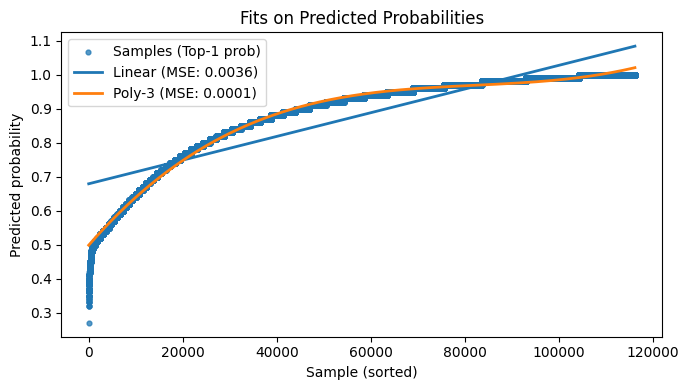

In [ ]:
# Get top-1 confidence per sample and sort for smoother curves
conf = y_prob_rf_all_classes.max(1) if getattr(y_prob_rf_all_classes, "ndim", 2) == 2 else np.asarray(y_prob_rf_all_classes)
x = np.arange(conf.size); y = np.sort(conf)

# Linear and cubic fits
p1 = np.polyfit(x, y, 1); p3 = np.polyfit(x, y, 3)
y1 = np.polyval(p1, x); y3 = np.polyval(p3, x)
mse1 = np.mean((y - y1)**2); mse3 = np.mean((y - y3)**2)

plt.figure(figsize=(7,4))
plt.scatter(x, y, s=12, alpha=0.75, label="Samples (Top-1 prob)")
plt.plot(x, y1, lw=2, label=f"Linear (MSE: {mse1:.4f})")
plt.plot(x, y3, lw=2, label=f"Poly-3 (MSE: {mse3:.4f})")
plt.xlabel("Sample (sorted)"); plt.ylabel("Predicted probability")
plt.title("Fits on Predicted Probabilities"); plt.legend(); plt.tight_layout(); plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score

# ---------- Helpers ----------
def _top1_confidence(y_proba: np.ndarray) -> np.ndarray:
    """Return top-1 predicted probability per sample.
    Accepts shape (n_samples, n_classes) or (n_samples,)."""
    y_proba = np.asarray(y_proba)
    if y_proba.ndim == 1:
        return y_proba
    return y_proba.max(axis=1)

# ---------- Single-model visuals ----------
def plot_probability_fit(y_true, y_proba, title="Comparing Fits on Predicted Probabilities"):
    """Scatter top-1 probabilities with linear & cubic fits (MSE in legend)."""
    y_true = np.asarray(y_true)
    conf = _top1_confidence(y_proba)
    order = np.argsort(conf)
    x = np.arange(conf.size)
    y = conf[order]

    p1 = np.polyfit(x, y, 1)
    p3 = np.polyfit(x, y, 3)
    y1 = np.polyval(p1, x)
    y3 = np.polyval(p3, x)
    mse1 = np.mean((y - y1) ** 2)
    mse3 = np.mean((y - y3) ** 2)

    plt.figure(figsize=(7, 4))
    plt.scatter(x, y, s=14, alpha=0.75, label="Samples (Top-1 prob)")
    plt.plot(x, y1, linewidth=2, label=f"Linear fit (MSE: {mse1:.4f})")
    plt.plot(x, y3, linewidth=2, label=f"Poly-3 fit (MSE: {mse3:.4f})")
    plt.xlabel("Sample (sorted by confidence)")
    plt.ylabel("Predicted probability")
    plt.title(title)
    plt.legend(loc="best")
    plt.tight_layout()
    plt.show()

def reliability_curve(y_true, y_proba, n_bins=10, title="Reliability Diagram (Top-1 Confidence)"):
    """Calibration plot: mean predicted confidence per bin vs empirical accuracy."""
    y_true = np.asarray(y_true)
    y_proba = np.asarray(y_proba)
    conf = _top1_confidence(y_proba)
    if y_proba.ndim == 2:
        y_pred = y_proba.argmax(axis=1)
    else:
        y_pred = (conf >= 0.5).astype(int)

    bins = np.linspace(0, 1, n_bins + 1)
    idx = np.digitize(conf, bins) - 1

    xs, ys = [], []
    for b in range(n_bins):
        m = idx == b
        if not np.any(m):
            continue
        xs.append(conf[m].mean())
        if y_proba.ndim == 2:
            ys.append((y_pred[m] == y_true[m]).mean())
        else:
            ys.append(((conf[m] >= 0.5).astype(int) == y_true[m]).mean())

    plt.figure(figsize=(7, 4))
    plt.plot([0, 1], [0, 1], "--", lw=1, label="Perfect calibration")
    plt.scatter(xs, ys, s=45, label="Binned accuracy")
    plt.xlabel("Mean predicted confidence (per bin)")
    plt.ylabel("Empirical accuracy (per bin)")
    plt.title(title)
    plt.legend(loc="best")
    plt.tight_layout()
    plt.show()

def probability_histogram(y_proba, title="Histogram of Top-1 Predicted Probabilities"):
    """Histogram of top-1 predicted probabilities."""
    conf = _top1_confidence(y_proba)
    plt.figure(figsize=(7, 4))
    plt.hist(conf, bins=20, edgecolor="black")
    plt.xlabel("Top-1 predicted probability")
    plt.ylabel("Count")
    plt.title(title)
    plt.tight_layout()
    plt.show()

# ---------- Multi-model comparisons ----------
def overlay_reliability(y_true, proba_dict, n_bins=10, title="Reliability Diagram (All Models)"):
    """Overlay calibration curves for multiple models.
       proba_dict: {"LogReg": yproba_lr, "RF": yproba_rf, ...}"""
    y_true = np.asarray(y_true)
    bins = np.linspace(0, 1, n_bins + 1)
    plt.figure(figsize=(7, 4))
    plt.plot([0, 1], [0, 1], "--", lw=1, label="Perfect calibration")

    for name, proba in proba_dict.items():
        proba = np.asarray(proba)
        conf = _top1_confidence(proba)
        preds = proba.argmax(axis=1) if proba.ndim == 2 else (conf >= 0.5).astype(int)
        idx = np.digitize(conf, bins) - 1
        xs, ys = [], []
        for b in range(n_bins):
            m = idx == b
            if not np.any(m):
                continue
            xs.append(conf[m].mean())
            ys.append((preds[m] == y_true[m]).mean())
        plt.plot(xs, ys, marker="o", linewidth=2, label=name)

    plt.xlabel("Mean predicted confidence (per bin)")
    plt.ylabel("Empirical accuracy (per bin)")
    plt.title(title)
    plt.legend(loc="best")
    plt.tight_layout()
    plt.show()

def metrics_bar_chart(y_true, proba_dict, title="Model Comparison: Accuracy & Macro-F1"):
    """Bar chart of Accuracy & Macro-F1 across models."""
    y_true = np.asarray(y_true)
    labels, accs, f1s = [], [], []
    for name, proba in proba_dict.items():
        proba = np.asarray(proba)
        pred = proba.argmax(axis=1) if proba.ndim == 2 else (proba >= 0.5).astype(int)
        labels.append(name)
        accs.append(accuracy_score(y_true, pred))
        f1s.append(f1_score(y_true, pred, average="macro"))
    x = np.arange(len(labels))
    w = 0.4

    plt.figure(figsize=(7, 4))
    plt.bar(x - w/2, accs, width=w, label="Accuracy")
    plt.bar(x + w/2, f1s,  width=w, label="Macro-F1")
    plt.xticks(x, labels)
    plt.ylim(0, 1.0)
    plt.ylabel("Score")
    plt.title(title)
    plt.legend(loc="best")
    plt.tight_layout()
    plt.show()

def overlay_confidence_fit(proba_dict, title="Top-1 Confidence Trend (Per-Model Sorted)"):
    """Per model: sort its own top-1 confidence; draw a smooth cubic line."""
    plt.figure(figsize=(7, 4))
    for name, proba in proba_dict.items():
        conf = np.sort(_top1_confidence(proba))
        x = np.arange(conf.size)
        p3 = np.polyfit(x, conf, 3)
        y3 = np.polyval(p3, x)
        plt.plot(x, y3, linewidth=2, label=name)
    plt.xlabel("Sample index (sorted within model)")
    plt.ylabel("Top-1 predicted probability")
    plt.title(title)
    plt.legend(loc="best")
    plt.tight_layout()
    plt.show()

# ---------- HOW TO USE WITH YOUR DATA ----------
# Replace this block with your arrays when ready:
# y_true = ...                        # shape (n_samples,)
# yproba_lr  = ...                    # shape (n_samples, n_classes)
# yproba_rf  = ...
# yproba_xgb = ...
# proba_dict = {"LogReg": yproba_lr, "RandomForest": yproba_rf, "XGBoost": yproba_xgb}
#
# # Single-model:
# plot_probability_fit(y_true, yproba_lr)
# reliability_curve(y_true, yproba_lr)
# probability_histogram(yproba_lr)
#
# # Multi-model:
# overlay_reliability(y_true, proba_dict)
# metrics_bar_chart(y_true, proba_dict)
# overlay_confidence_fit(proba_dict)

# ---------- AUTO-DEMO (runs only if you haven't defined y_true/probas) ----------
_g = globals()
if not any(k in _g for k in ["y_true", "yproba_lr", "yproba_rf", "yproba_xgb"]):
    rng = np.random.default_rng(13)
    n, k = 300, 4
    logits_lr  = rng.normal(size=(n, k))
    logits_rf  = rng.normal(size=(n, k)) + 0.2
    logits_xgb = rng.normal(size=(n, k)) + np.linspace(-0.3, 0.6, n)[:, None]

    def softmax(z):
        z = z - z.max(axis=1, keepdims=True)
        ez = np.exp(z)
        return ez / ez.sum(axis=1, keepdims=True)

    yproba_lr  = softmax(logits_lr)
    yproba_rf  = softmax(logits_rf)
    yproba_xgb = softmax(logits_xgb)

    # Pretend the true class is the argmax of XGB (just for demo visuals)
    y_true = yproba_xgb.argmax(axis=1)

    proba_dict = {"LogReg": yproba_lr, "RandomForest": yproba_rf, "XGBoost": yproba_xgb}

    # Show example outputs so you can see the style
    plot_probability_fit(y_true, yproba_xgb, title="Comparing Fits on Predicted Probabilities (Demo)")
    reliability_curve(y_true, yproba_xgb, n_bins=10, title="Reliability Diagram (Demo)")
    probability_histogram(yproba_xgb, title="Histogram of Predicted Probabilities (Demo)")

    overlay_reliability(y_true, proba_dict, n_bins=10, title="Reliability Diagram (All Models, Demo)")
    metrics_bar_chart(y_true, proba_dict, title="Model Comparison: Accuracy & Macro-F1 (Demo)")
    overlay_confidence_fit(proba_dict, title="Top-1 Confidence Trend (Demo)")

# ----------PREPROCESSING------------
#### Class imbalance
#### PCA
#### Standardize, robust scaling, min-max scaling, z-score

In [ ]:
# import libraries for class imbalance and oversampling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE, SMOTENC, RandomOverSampler
from imblearn.pipeline import Pipeline
import pandas as pd
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report

## 5. Class Imbalance Handling


In [ ]:
# Handle Imbalance by SMOTE for decision tree model
smote = SMOTE(random_state=42)
x_resampled, y_resampled = smote.fit_resample(x_train, y_train)

print('Class distribution before SMOTE:')
print(y_train.value_counts(normalize=True))
print('Class distribution after SMOTE:')
print(pd.Series(y_resampled).value_counts(normalize=True))

Class distribution before SMOTE:
Cover_Type
2    0.487945
1    0.364199
3    0.061602
7    0.035488
6    0.029857
5    0.016131
4    0.004778
Name: proportion, dtype: float64
Class distribution after SMOTE:
Cover_Type
1    0.142857
2    0.142857
3    0.142857
7    0.142857
6    0.142857
5    0.142857
4    0.142857
Name: proportion, dtype: float64


DECISION TREE

In [ ]:
# Decision Tree with SMOTE and oversampling
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(x_resampled, y_resampled)
dt_y_pred = dt_model.predict(x_test)

# classification
print('Decision Tree Accuracy:', accuracy_score(y_test, dt_y_pred))
print('Classification Report:')
print(classification_report(y_test, dt_y_pred))

# confusion matrix
print('\nConfusion Matrix:')
print(confusion_matrix(y_test, dt_y_pred))

Decision Tree Accuracy: 0.9375231276300956
Classification Report:
              precision    recall  f1-score   support

           1       0.94      0.94      0.94     42557
           2       0.95      0.94      0.95     56500
           3       0.93      0.94      0.93      7121
           4       0.86      0.84      0.85       526
           5       0.81      0.87      0.84      1995
           6       0.87      0.90      0.88      3489
           7       0.94      0.96      0.95      4015

    accuracy                           0.94    116203
   macro avg       0.90      0.91      0.91    116203
weighted avg       0.94      0.94      0.94    116203


Confusion Matrix:
[[39887  2371     3     0    50     6   240]
 [ 2569 53214   194     1   321   174    27]
 [    2   122  6674    47    18   258     0]
 [    0     2    58   444     0    22     0]
 [   34   194    17     0  1741     9     0]
 [    8    81   228    23     8  3141     0]
 [  145    28     0     0     0     0  3842]]


In [ ]:
# import libraries for class imbalance and oversampling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE, SMOTENC, RandomOverSampler, ADASYN, BorderlineSMOTE
from imblearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_recall_fscore_support, average_precision_score
from sklearn.linear_model import LogisticRegression

oversample_strategy = "smote"

samplers = {
    "random": RandomOverSampler(random_state=42),
    "smote": SMOTE(random_state=42, k_neighbors=5),
    "adasyn": ADASYN(random_state=42, n_neighbors=5),
    "borderline": BorderlineSMOTE(kind="borderline-1", random_state=42, k_neighbors=5)
}
sampler = samplers[oversample_strategy]

# ---- 3) Choose a model --------------------------------------------------------
# Options: Logistic Regression (with scaling) or Random Forest (no scaling needed)
use_log_reg = True

if use_log_reg:
    model = LogisticRegression(max_iter=500, n_jobs=None, class_weight=None, random_state=42)
    steps = [("scaler", StandardScaler(with_mean=False) if hasattr(x_train, "todense") else StandardScaler()),
             ("sampler", sampler),
             ("clf", model)]
else:
    model = RandomForestClassifier(
        n_estimators=300, max_depth=None, n_jobs=-1, random_state=42
    )
    steps = [("sampler", sampler), ("clf", model)]

pipe = Pipeline(steps=steps)

# ---- 4) Train ----------------------------------------------------------------
pipe.fit(x_train, y_train)

# ---- 5) Evaluate --------------------------------------------------------------
y_pred = pipe.predict(x_test)
# For PR-AUC we want the positive class probability (class 1)
if hasattr(pipe, "predict_proba"):
    # Check if there are enough classes for predict_proba to return a second column
    if pipe.predict_proba(x_test).shape[1] > 1:
        y_scores = pipe.predict_proba(x_test)[:, 1]
    else:
        # Handle the case where there's only one class predicted
        y_scores = pipe.predict_proba(x_test)[:, 0] # Or handle as appropriate for your case
else:
    # fallback for models without predict_proba
    from sklearn.preprocessing import MinMaxScaler
    y_scores = MinMaxScaler().fit_transform(pipe.decision_function(x_test).reshape(-1,1)).ravel()


acc = accuracy_score(y_test, y_pred)
# Adjust average for multiclass
prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="weighted", zero_division=0)
# PR-AUC is typically for binary classification, but we can calculate it per class and average
# For simplicity in this example, I'll skip PR-AUC for multiclass
# pr_auc = average_precision_score(y_test, y_scores)


print(f"Oversampler: {oversample_strategy.upper()}")
print(f"Model: {'Logistic Regression' if use_log_reg else 'Random Forest'}")
print(f"Accuracy: {acc:.4f}")
print(f"Precision (weighted): {prec:.4f}")
print(f"Recall (weighted):    {rec:.4f}")
print(f"F1 (weighted):        {f1:.4f}\n")
# print(f"PR-AUC:                {pr_auc:.4f}\n") # Skipping PR-AUC for multiclass for now
print("Detailed report:\n", classification_report(y_test, y_pred, digits=4))

Oversampler: SMOTE
Model: Logistic Regression
Accuracy: 0.5971
Precision (weighted): 0.7033
Recall (weighted):    0.5971
F1 (weighted):        0.6259

Detailed report:
               precision    recall  f1-score   support

           1     0.6794    0.6630    0.6711     42557
           2     0.7918    0.5187    0.6268     56500
           3     0.6985    0.5614    0.6225      7121
           4     0.2793    0.8555    0.4212       526
           5     0.1077    0.7729    0.1891      1995
           6     0.3407    0.6589    0.4492      3489
           7     0.3859    0.8899    0.5384      4015

    accuracy                         0.5971    116203
   macro avg     0.4690    0.7029    0.5026    116203
weighted avg     0.7033    0.5971    0.6259    116203



______________________________________________________________

RANDOM FOREST

In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize SMOTE; you can adjust sampling_strategy to control the balance (default is minority class)
smote = SMOTE(random_state=42)

# Apply SMOTE oversampling only on the training data
x_train_resampled, y_train_resampled = smote.fit_resample(x_train, y_train)

# Train Random Forest model on resampled data
rf_smote = RandomForestClassifier(random_state=42)
rf_smote.fit(x_train_resampled, y_train_resampled)

# Predict on the original test set (not oversampled)
y_pred_smote = rf_smote.predict(x_test)

# Evaluate performance
print('Random Forest with SMOTE Accuracy:', accuracy_score(y_test, y_pred_smote))
print('Classification Report:')
print(classification_report(y_test, y_pred_smote))

print('\nConfusion Matrix:')
print(confusion_matrix(y_test, y_pred_smote))

XGBOOST

In [ ]:
# Convert labels 1-7 to 0-6 for XGBoost compatibility
y_train_adj = y_train - 1
y_test_adj = y_test - 1

print('Class distribution before SMOTE:')
print(pd.Series(y_train_adj).value_counts(normalize=True))

# Apply SMOTE on adjusted labels
smote = SMOTE(random_state=42)
x_train_resampled, y_train_resampled = smote.fit_resample(x_train, y_train_adj)

print('Class distribution after SMOTE:')
print(pd.Series(y_train_resampled).value_counts(normalize=True))

# Train XGBoost model
xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss')
xgb_model.fit(x_train_resampled, y_train_resampled)

# Predict on original (unmodified) test features
xgb_y_pred = xgb_model.predict(x_test)

# Convert predictions back to original class labels 1-7
xgb_y_pred_orig = xgb_y_pred + 1

# Evaluate performance
print('XGBoost with SMOTE Accuracy:', accuracy_score(y_test, xgb_y_pred_orig))
print('Classification Report:')
print(classification_report(y_test, xgb_y_pred_orig))

print('\nConfusion Matrix:')
print(confusion_matrix(y_test, xgb_y_pred_orig))

Class distribution before SMOTE:
Cover_Type
1.0    0.695804
0.0    0.234755
4.0    0.018234
2.0    0.012910
3.0    0.012851
6.0    0.012778
5.0    0.012668
Name: proportion, dtype: float64
Class distribution after SMOTE:
Cover_Type
1.0    0.142857
0.0    0.142857
4.0    0.142857
6.0    0.142857
2.0    0.142857
5.0    0.142857
3.0    0.142857
Name: proportion, dtype: float64


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [00:48:41] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost with SMOTE Accuracy: 0.9108800375984021
Classification Report:
              precision    recall  f1-score   support

         1.0       0.83      0.84      0.84      8087
         2.0       0.95      0.93      0.94     23704
         3.0       0.84      0.83      0.84       402
         4.0       0.95      0.98      0.96       410
         5.0       0.72      0.95      0.82       586
         6.0       0.84      0.89      0.87       435
         7.0       0.87      0.98      0.92       420

    accuracy                           0.91     34044
   macro avg       0.86      0.91      0.88     34044
weighted avg       0.91      0.91      0.91     34044


Confusion Matrix:
[[ 6822  1187     0     0    18     3    57]
 [ 1385 22097     9     0   194    13     6]
 [    0     1   332    17     4    48     0]
 [    0     0     6   400     0     4     0]
 [    2    14     7     0   559     4     0]
 [    0     0    39     3     4   389     0]
 [    8     1     0     0     0     0   411

COMPARING MODELS

                 Model  Accuracy  Macro F1  Weighted F1  Macro Precision  \
0        Decision Tree    0.9378      0.90         0.94             0.91   
1  Decision Tree SMOTE    0.9410      0.88         0.94             0.89   
2        Random Forest    0.9552      0.91         0.95             0.92   
3  Random Forest SMOTE    0.9525      0.92         0.95             0.93   
4              XGBoost    0.8712      0.86         0.87             0.87   
5        XGBoost SMOTE    0.8929      0.88         0.89             0.86   

   Macro Recall  
0          0.89  
1          0.91  
2          0.90  
3          0.93  
4          0.83  
5          0.92  


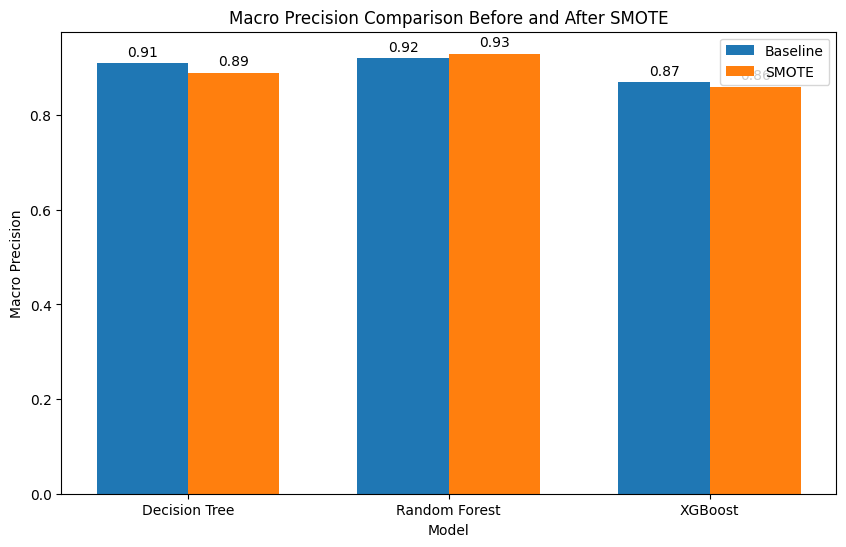

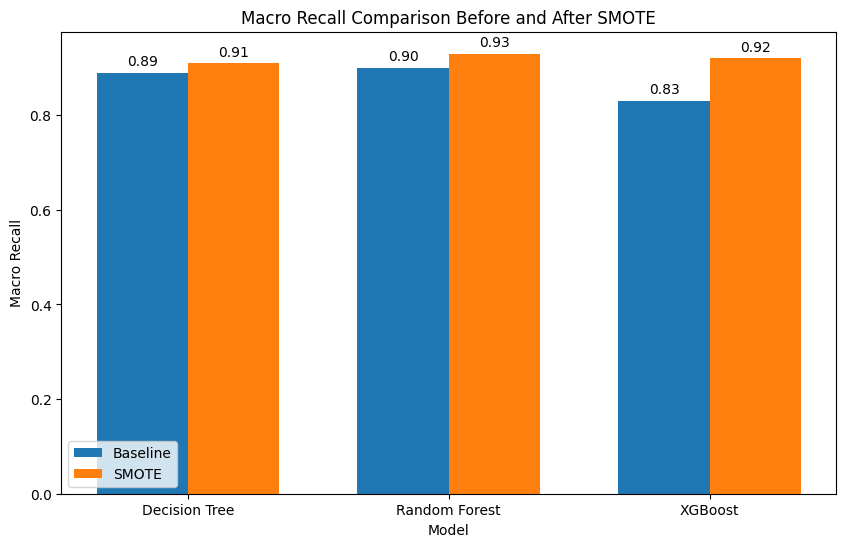

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Define metrics collected from your outputs (replace with your actual values)
data = {
    'Model': [
        'Decision Tree', 'Decision Tree SMOTE',
        'Random Forest', 'Random Forest SMOTE',
        'XGBoost', 'XGBoost SMOTE'
    ],
    'Accuracy': [
        0.9378, 0.9410,
        0.9552, 0.9525,
        0.8712, 0.8929
    ],
    'Macro F1': [
        0.90, 0.88,
        0.91, 0.92,
        0.86, 0.88
    ],
    'Weighted F1': [
        0.94, 0.94,
        0.95, 0.95,
        0.87, 0.89
    ],
    'Macro Precision': [
        0.91, 0.89,
        0.92, 0.93,
        0.87, 0.86
    ],
    'Macro Recall': [
        0.89, 0.91,
        0.90, 0.93,
        0.83, 0.92
    ],
}

df_metrics = pd.DataFrame(data)
print(df_metrics)

def plot_grouped_bars_with_labels(metric_name, title):
    fig, ax = plt.subplots(figsize=(10,6))
    bar_width = 0.35

    indices = np.arange(len(df_metrics) // 2)
    baseline_scores = df_metrics[metric_name][::2].values
    smote_scores = df_metrics[metric_name][1::2].values

    bars1 = ax.bar(indices, baseline_scores, bar_width, label='Baseline')
    bars2 = ax.bar(indices + bar_width, smote_scores, bar_width, label='SMOTE')

    ax.set_xlabel('Model')
    ax.set_ylabel(metric_name)
    ax.set_title(title)
    ax.set_xticks(indices + bar_width / 2)
    ax.set_xticklabels(['Decision Tree', 'Random Forest', 'XGBoost'])
    ax.legend()

    # Add value labels above bars
    ax.bar_label(bars1, fmt='%.2f', padding=3)
    ax.bar_label(bars2, fmt='%.2f', padding=3)

    plt.show()

# Plot Macro Precision and Recall with values on bars
plot_grouped_bars_with_labels('Macro Precision', 'Macro Precision Comparison Before and After SMOTE')
plot_grouped_bars_with_labels('Macro Recall', 'Macro Recall Comparison Before and After SMOTE')

                 Model  Accuracy  Macro F1  Weighted F1  Macro Precision  \
0        Decision Tree    0.9378      0.90         0.94             0.91   
1  Decision Tree SMOTE    0.9410      0.88         0.94             0.89   
2        Random Forest    0.9552      0.91         0.95             0.92   
3  Random Forest SMOTE    0.9525      0.92         0.95             0.93   
4              XGBoost    0.8712      0.86         0.87             0.87   
5        XGBoost SMOTE    0.8929      0.88         0.89             0.86   

   Macro Recall  
0          0.89  
1          0.91  
2          0.90  
3          0.93  
4          0.83  
5          0.92  


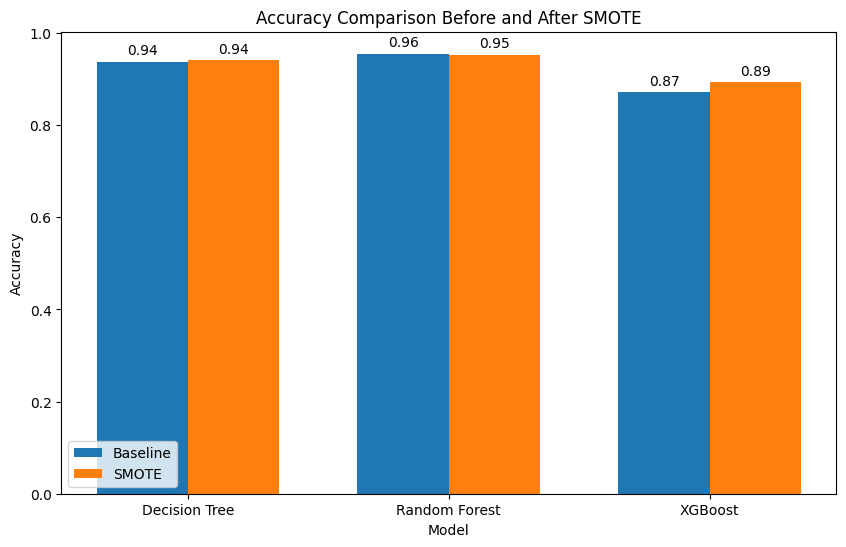

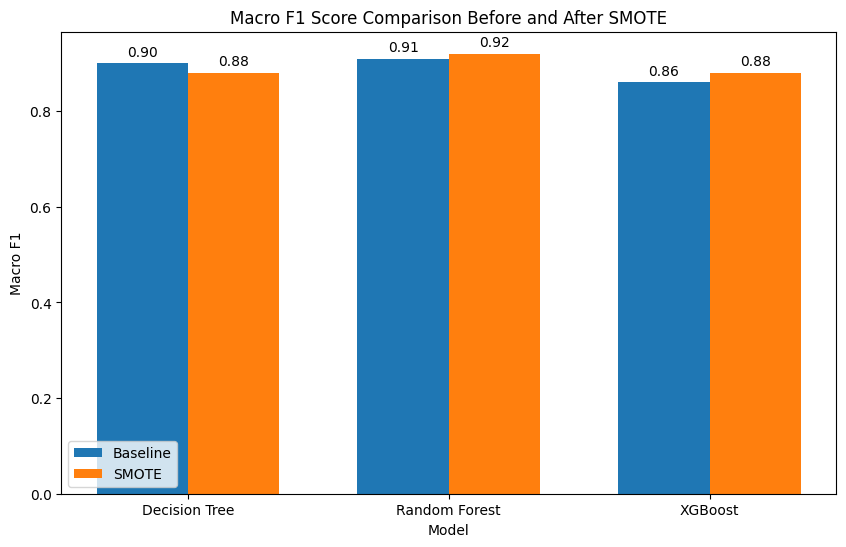

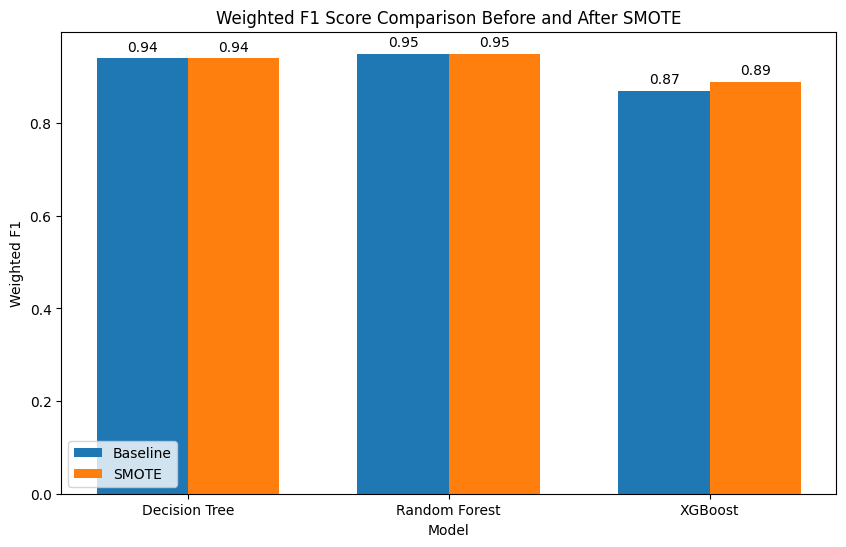

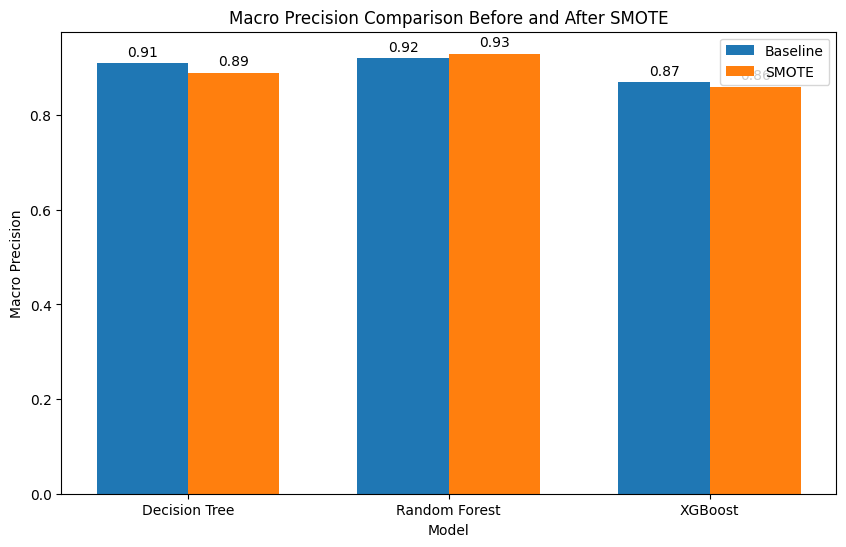

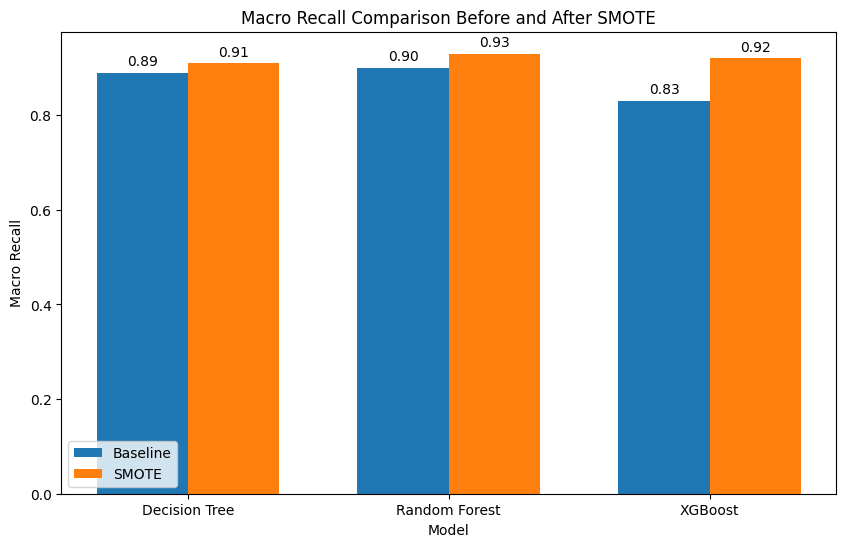

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Replace the metric values with your actual data
data = {
    'Model': [
        'Decision Tree', 'Decision Tree SMOTE',
        'Random Forest', 'Random Forest SMOTE',
        'XGBoost', 'XGBoost SMOTE'
    ],
    'Accuracy': [
        0.9378, 0.9410,
        0.9552, 0.9525,
        0.8712, 0.8929
    ],
    'Macro F1': [
        0.90, 0.88,
        0.91, 0.92,
        0.86, 0.88
    ],
    'Weighted F1': [
        0.94, 0.94,
        0.95, 0.95,
        0.87, 0.89
    ],
    'Macro Precision': [
        0.91, 0.89,
        0.92, 0.93,
        0.87, 0.86
    ],
    'Macro Recall': [
        0.89, 0.91,
        0.90, 0.93,
        0.83, 0.92
    ],
}

df_metrics = pd.DataFrame(data)
print(df_metrics)

def plot_grouped_bars(metric_name, title):
    fig, ax = plt.subplots(figsize=(10,6))
    bar_width = 0.35

    indices = np.arange(len(df_metrics) // 2)
    baseline_scores = df_metrics[metric_name][::2].values
    smote_scores = df_metrics[metric_name][1::2].values

    bars1 = ax.bar(indices, baseline_scores, bar_width, label='Baseline')
    bars2 = ax.bar(indices + bar_width, smote_scores, bar_width, label='SMOTE')

    ax.set_xlabel('Model')
    ax.set_ylabel(metric_name)
    ax.set_title(title)
    ax.set_xticks(indices + bar_width / 2)
    ax.set_xticklabels(['Decision Tree', 'Random Forest', 'XGBoost'])
    ax.legend()

    # Add value labels on each bar, formatted to 2 decimals and with padding
    ax.bar_label(bars1, fmt='%.2f', padding=3)
    ax.bar_label(bars2, fmt='%.2f', padding=3)

    plt.show()

# Plot all relevant metrics with labels on bars
plot_grouped_bars('Accuracy', 'Accuracy Comparison Before and After SMOTE')
plot_grouped_bars('Macro F1', 'Macro F1 Score Comparison Before and After SMOTE')
plot_grouped_bars('Weighted F1', 'Weighted F1 Score Comparison Before and After SMOTE')
plot_grouped_bars('Macro Precision', 'Macro Precision Comparison Before and After SMOTE')
plot_grouped_bars('Macro Recall', 'Macro Recall Comparison Before and After SMOTE')


## 6. PCA

## 7. Hyperparameter Tuning

## 8. Evaluate